In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [10]:
from utils import add_decision_boundary

In [ ]:
merged = pd.read_csv("../data/merged.csv")
print(merged.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures_mat', 'schoolsup', 'famsup', 'paid_mat', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences_mat', 'G1_mat', 'G2_mat',
       'G3_mat', 'failures_por', 'paid_por', 'absences_por', 'G1_por',
       'G2_por', 'G3_por'],
      dtype='object')


In [3]:
# prep

num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
 
# l'élève/études supérieures ?
merged_model = merged[num_cols + ['higher']].dropna()
X_raw = merged_model[num_cols].values
y = (merged_model['higher'] == 'yes').astype(int).values
 
# Normalisation 
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
 
print(f"{X.shape[0]} individus | classes : {np.bincount(y)} (0=non, 1=oui)")

674 individus | classes : [ 73 601] (0=non, 1=oui)


K optimal : 5 | Accuracy CV : 0.900


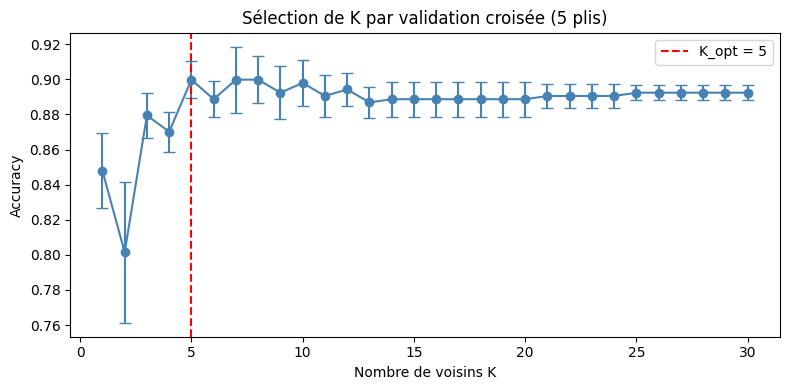

In [4]:
# sep train/test
 
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
#validation croisée
 
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": range(1, 31)},
    scoring="accuracy",
    cv=5
)
grid.fit(X_dev, y_dev)
 
K_opt = grid.best_params_["n_neighbors"]
print(f"K optimal : {K_opt} | Accuracy CV : {grid.best_score_:.3f}")
 
# courbe de sélection
results = grid.cv_results_
ks = np.array(results["param_n_neighbors"].data, dtype=int)
 
plt.figure(figsize=(8, 4))
plt.errorbar(ks, results["mean_test_score"], yerr=results["std_test_score"],
             fmt="o-", capsize=4, color="steelblue")
plt.axvline(K_opt, color="red", linestyle="--", label=f"K_opt = {K_opt}")
plt.title("Sélection de K par validation croisée (5 plis)")
plt.xlabel("Nombre de voisins K")
plt.ylabel("Accuracy")
plt.legend(); plt.tight_layout()
plt.show()

In [5]:

 # estimation final (nn bisaisée)

 
acc_test = np.mean(y_test == grid.best_estimator_.predict(X_test))
print(f"Accuracy finale sur jeu de test : {acc_test:.3f}")

Accuracy finale sur jeu de test : 0.881


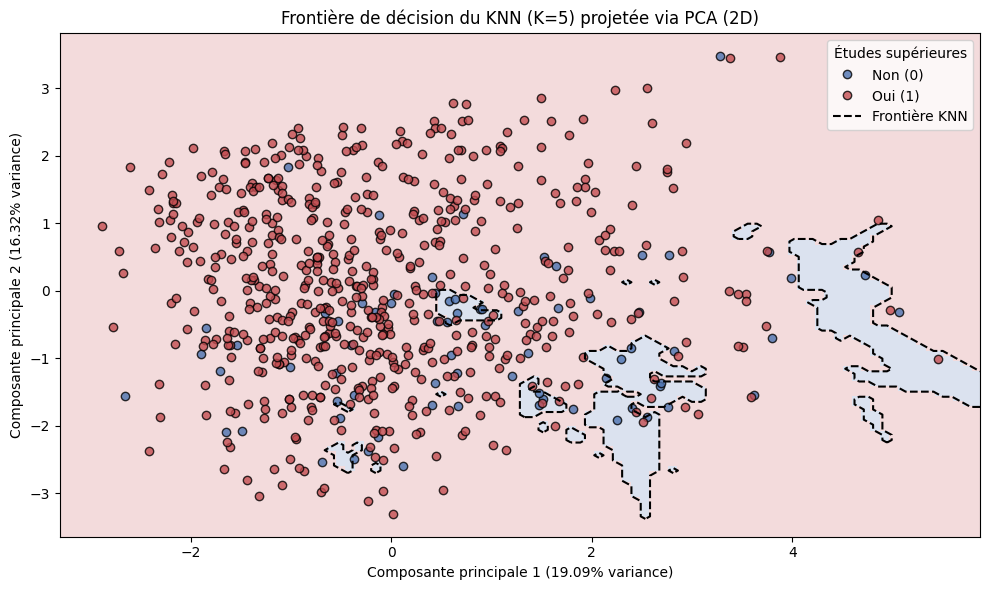

In [13]:
# Réduction de dimension avec PCA pour la visualisation (2 composantes principales)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) # Utilisation de X (déjà normalisé)

# Entraînement du modèle K=5 sur les données 2D
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_pca, y)

# Figure
fig, ax = plt.subplots(figsize=(10, 6))

couleurs = ['#4c72b0', '#c44e52'] 

for c, color in zip(knn_pca.classes_, couleurs):
    mask = (y == c)
    ax.plot(
        X_pca[mask, 0], X_pca[mask, 1],
        marker='o', linestyle='', 
        color=color, 
        label=str(c),  # C'est ce label précis que utils.py cherche !
        markeredgecolor='k', markersize=6, alpha=0.8
    )

add_decision_boundary(
    model=knn_pca,
    ax=ax,
    label="Frontière KNN",
    color="black",
    region=True
)

# Renommer les labels de la légende pour l'affichage final
handles, labels = ax.get_legend_handles_labels()
nouveaux_labels = ["Non (0)" if l == "0" else "Oui (1)" if l == "1" else l for l in labels]
ax.legend(handles, nouveaux_labels, title="Études supérieures")

# 4. Ajout des titres et labels des axes
ax.set_title("Frontière de décision du KNN (K=5) projetée via PCA (2D)")
ax.set_xlabel(f"Composante principale 1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
ax.set_ylabel(f"Composante principale 2 ({pca.explained_variance_ratio_[1]:.2%} variance)")

plt.tight_layout()
plt.show()

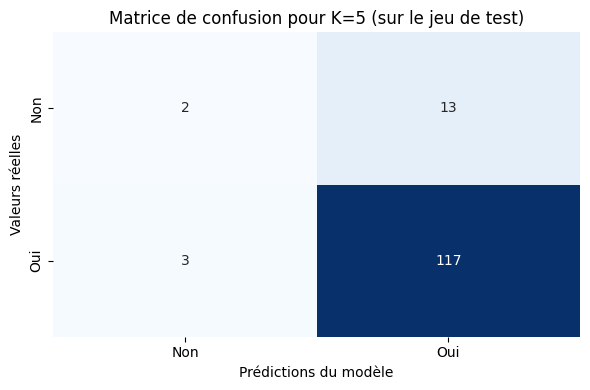

In [14]:
from sklearn.metrics import confusion_matrix

# Utilisation du meilleur modèle (K=5) issu du GridSearchCV
y_pred = grid.best_estimator_.predict(X_test)

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Visualisation avec Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Non", "Oui"], 
            yticklabels=["Non", "Oui"])

plt.title("Matrice de confusion pour K=5 (sur le jeu de test)")
plt.xlabel("Prédictions du modèle")
plt.ylabel("Valeurs réelles")
plt.tight_layout()
plt.show()